# Tutorial05 · Spam Email Classification

From simple rules to reliable decisions

**Tutor:** Yinghao Zhu · yhzhu99@connect.hku.hk

Build a filter that catches spam without hiding real messages, then decide where to draw the line.

We start with a keyword rule anyone could write, see where it fails, and fix one problem at a time: better features, learned word weights, controlled complexity, fair model selection and a decision threshold. The data are 5,574 labelled SMS messages from the UCI SMS Spam Collection. Short texts keep every step easy to inspect; the results do not transfer directly to modern email.

## Learning route

1. **Start with the inbox** — What should a spam filter actually do?
2. **Know the data** — What does this dataset let us learn?
3. **Build observable features** — What can we measure before understanding language?
4. **Turn words into vectors** — How can the model use the actual words?
5. **Learn a weighted rule** — How do word counts become a spam score?
6. **Control the fitted rule** — Should one rare word receive a huge weight?
7. **Select with cross-validation** — What must be fitted again inside each fold?
8. **Model the class distributions** — What changes if we model the features within each class?
9. **Allow smooth feature effects** — Must each extra character change the score by the same amount?
10. **Learn from similar messages** — What makes two messages neighbours?
11. **Choose the final decision** — How should scores become inbox actions?

## Learning objectives

- Explain why accuracy can mislead on imbalanced data, and what train / validation / test are each for.
- Turn text into numerical features, word counts and TF–IDF vectors.
- Read a logistic prediction as a sum of word contributions, and explain how C changes the weights.
- Use cross-validation without leaking information from held-out folds.
- Compare logistic regression, LDA, a GAM and KNN by their assumptions and validation results.
- Choose a threshold from the precision–recall trade-off and report a one-time test result.

**Prerequisites:** Basic Python and NumPy. From lectures: logistic regression, LDA, GAMs, KNN, regularization, cross-validation and classification metrics.

**Outcome:** An executed notebook with your baselines, model comparisons, chosen threshold, final test result and one limitation of the data.

Each section explains the mechanism, plots or inspects an actual computation, then runs an editable experiment. All sections form the classroom lesson.

## Data source and setup

# Original UCI SMS Spam Collection

**Source:** Almeida, T. A. and Gómez Hidalgo, J. M. (2011), SMS Spam Collection,
UCI Machine Learning Repository.
https://archive.ics.uci.edu/dataset/228/sms+spam+collection
Dataset DOI: https://doi.org/10.24432/C5CC84
Original archive: https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip

`SMSSpamCollection.txt` contains the original archive's `SMSSpamCollection` bytes,
unchanged; only the local filename has a `.txt` extension. Downloaded 2026-10-05.
It has 5,574 tab-separated label/message records: 4,827 ham and 747 spam.
UCI currently lists CC BY 4.0; original attribution/terms are in SOURCE-LICENSE.txt.

**Paper:** Almeida, T. A., Gómez Hidalgo, J. M., and Yamakami, A. (2011),
“Contributions to the Study of SMS Spam Filtering: New Collection and Results,”
ACM Symposium on Document Engineering. https://doi.org/10.1145/2034691.2034742

The English messages were compiled from Grumbletext (UK spam complaints), the NUS
SMS Corpus (volunteer messages, largely Singaporean students), Caroline Tagg's PhD
research and the SMS Spam Corpus v0.1 Big. It is a compiled research corpus, not a
random sample of today's inboxes. Messages are not chronologically ordered.

Why use it: short inspectable examples, explicit binary labels, manageable local training,
class imbalance and repeated messages make representation and evaluation choices visible.
Despite the tutorial title Spam Email Classification, these are SMS messages, without
email senders, subjects, attachments or headers. Text-classification methods transfer;
measured performance does not establish results on modern email, phishing, other
languages or another population. Constructed inbox cards are illustrative examples.

The loader checks empty/placeholder messages, normalizes case/whitespace solely for
message identity, rejects conflicting labels, and keeps one record per identity before
splitting. It reports every count and preserves retained message text. Splits are
stratified 60% train / 20% validation / 20% test (seed 3612). Five-fold CV uses training
only. Vocabulary, IDF, scaling and spline knots belong inside each fold's fitted pipeline.

SHA-256 of the unchanged original file:
7d039a24a6083ed9ef0f806ebad56bbb976e3aeb8de05669173bfdc4996c239d  src/tutorials/tutorial05/data/SMSSpamCollection.txt


Extract the complete student package. Keep `experiment.py` beside this notebook and retain `data/`. Install `requirements.txt`, then run cells in order. The original file is bundled locally; no dataset download or NLTK resources are required.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import experiment as science
from experiment import (Experiment, SEED, FEATURES, TOKEN_PATTERN, tokens, numerical_features,
                        load_data, rule_predict, decision_metrics, metrics, build_model, cross_validate,
                        CountVectorizer, TfidfVectorizer, Pipeline, FunctionTransformer,
                        StandardScaler, SplineTransformer, LogisticRegression,
                        LinearDiscriminantAnalysis, KNeighborsClassifier,
                        StratifiedKFold, train_test_split, average_precision_score,
                        confusion_matrix, log_loss, roc_auc_score)
import csv
import re

lab = Experiment("data/SMSSpamCollection.txt")
X_train, y_train = lab.X_train.copy(), lab.y_train.copy()
X_val, y_val = lab.X_val.copy(), lab.y_val.copy()
initial = lab.initialize()
print("Original / excluded / duplicate / retained:", initial["raw"], initial["excluded"], initial["duplicates"], initial["unique"])
print("Splits:", initial["counts"])
print("First lines of the raw file:")
for line in initial["preview"][:4]:
    print("  ", line.replace("\t", " ⇥ "))
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})
HAM, SPAM = "#45657e", "#aa613d"

Original / excluded / duplicate / retained: 5574 0 415 5159
Splits: {'train': {'total': 3095, 'ham': 2710, 'spam': 385}, 'validation': {'total': 1032, 'ham': 903, 'spam': 129}, 'test': {'total': 1032, 'ham': 904, 'spam': 128}}
First lines of the raw file:
   ham ⇥ Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
   ham ⇥ Ok lar... Joking wif u oni...
   spam ⇥ Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
   ham ⇥ U dun say so early hor... U c already then say...


## 1. Start with the inbox

**What should a spam filter actually do?**

**Key idea:** A spam filter makes decisions, and its two kinds of mistake cost different things.

- Label spam as 1 and normal messages (ham) as 0.
- Two mistakes: blocking a real message (false positive) or letting spam through (false negative). Losing an internship offer is worse than seeing one advert.
- The simplest filter: flag a message if it contains a keyword such as free, win or prize. Easy to explain, and easy to fool.

$$\hat y=\mathbb{1}\{\text{message contains a keyword}\}$$

- $y=1$: spam (the positive class)
- $y=0$: ham, a legitimate message
- $\hat y$: the filter's decision

**Try it**

1. Look at the four example messages. Which decisions are wrong?
2. Edit the keywords and apply the rule to real validation messages.
3. Read the mistakes. They motivate the rest of the tutorial.

### Inspect the implementation: `tokens`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [2]:
def tokens(text):
    """Simple, explicit tokenizer; the vectorizers use the same pattern."""
    return re.findall(TOKEN_PATTERN, text.lower())

science.tokens = tokens

### Inspect the implementation: `rule_predict`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [3]:
def rule_predict(messages, keywords=('free', 'win', 'prize')):
    """A transparent rule: flag when any selected whole-word token appears."""
    selected = set(keywords)
    return np.asarray([int(bool(selected.intersection(tokens(s)))) for s in messages])

science.rule_predict = rule_predict

In [4]:
rule_result = lab.rules({"keywords": "free win prize", "text": "Are you free after class?"})
print("Constructed normal message →", "spam" if rule_result["custom"] else "ham")
print("Validation metrics:", rule_result["metrics"])
for item in rule_result["errors"][:6]:
    print("True", item["label"], "predicted", item["prediction"], item["text"])

Constructed normal message → spam
Validation metrics: {'accuracy': 0.9176356589147286, 'precision': 0.8666666666666667, 'recall': 0.40310077519379844, 'f1': 0.5502645502645502, 'confusion': [[895, 8], [77, 52]], 'false_positive_rate': 0.008859357696566999, 'log_loss': 2.2758110192156895, 'average_precision': 0.4239664082687339, 'roc_auc': 0.6971207087486158}
True 1 predicted 0 SMS. ac sun0819 posts HELLO:"You seem cool, wanted to say hi. HI!!!" Stop? Send STOP to 62468
True 1 predicted 0 Santa Calling! Would your little ones like a call from Santa Xmas eve? Call 09058094583 to book your time.
True 1 predicted 0 RCT' THNQ Adrian for U text. Rgds Vatian
True 0 predicted 1 The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free
True 1 predicted 0 08714712388 between 10am-7pm Cost 10p
True 0 predicted 1 I prefer my free days... Tues, wed, fri oso can... Ü ask those workin lor...


### Run and explain

Add or remove one keyword. Which mistakes appear or disappear, and why?

In [5]:
keywords = ["free", "win", "prize"]
prediction = rule_predict(X_val, keywords)
print("Rule confusion:", metrics(y_val, prediction)["confusion"])
for text in ["Are you free after class?", "Claim your prize now"]:
    print(text, "→", rule_predict([text], keywords)[0])

Rule confusion: [[895, 8], [77, 52]]
Are you free after class? → 1
Claim your prize now → 1


**Takeaway:** A rule is a useful baseline. Its mistakes show why we need to combine many pieces of evidence and learn from data.

## 2. Know the data

**What does this dataset let us learn?**

**Key idea:** Know where the data come from, and keep the test set untouched.

- UCI SMS Spam Collection (Almeida et al., 2011): 5,574 English text messages, each labelled ham or spam. No email headers or subjects.
- Remove 415 duplicate messages before splitting, so the same text can never be in both training and test.
- Split 60 / 20 / 20. Train: fit models. Validation: compare models and pick a threshold. Test: use once, at the very end.
- Only 12% is spam. Predicting “ham” for everything already scores 87.5% accuracy, and catches no spam at all.

$$\mathrm{Accuracy}_{\text{always ham}}=\frac{n_{\mathrm{ham}}}{n}=\frac{903}{1032}=87.5\%$$

- $n$: messages in the validation split
- $n_{\mathrm{ham}}$: ham messages in that split
- $\text{stratified}$: every split keeps the same spam proportion

**Try it**

1. Look at the raw file, then browse and search the cleaned table.
2. Follow the counts from the raw file to the three splits.
3. Compare the always-ham baseline's accuracy with its spam recall.

### Inspect the implementation: `load_data`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [6]:
def load_data(path):
    """Deduplicate message identities BEFORE splitting; reject label conflicts."""
    with open(path, encoding='utf-8-sig', newline='') as handle:
        rows = list(csv.DictReader(handle, fieldnames=['Category', 'Message'],
                                   delimiter='\t', quoting=csv.QUOTE_NONE))
    unique = {}
    excluded = 0
    for row in rows:
        text, category = row['Message'], row['Category']
        if category not in ('ham', 'spam'):
            raise ValueError('Expected ham/spam Category.')
        if not text.strip() or text.strip() == '#ERROR!':
            excluded += 1
            continue
        # Identical after whitespace/case normalization must not cross splits.
        identity = ' '.join(text.lower().split())
        label = int(category == 'spam')
        if identity in unique and unique[identity][1] != label:
            raise ValueError('Conflicting labels for the same message.')
        unique.setdefault(identity, (text, label))
    messages = np.asarray([r[0] for r in unique.values()])
    labels = np.asarray([r[1] for r in unique.values()], dtype=int)
    train_val, test = train_test_split(np.arange(len(labels)), test_size=.2,
                                      stratify=labels, random_state=SEED)
    train, validation = train_test_split(train_val, test_size=.25,
                                       stratify=labels[train_val], random_state=SEED)
    return messages, labels, {'train': train, 'validation': validation, 'test': test}, {'raw': len(rows), 'excluded': excluded}

science.load_data = load_data

### Inspect the implementation: `decision_metrics`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [7]:
def decision_metrics(y, probability, threshold=.5):
    """Threshold-dependent decisions, computed once in the scientific layer."""
    p = np.asarray(probability, dtype=float)
    prediction = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, prediction, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if tp + fp else 0.
    recall = tp / (tp + fn) if tp + fn else 0.
    return {'accuracy': float((prediction == y).mean()), 'precision': float(precision),
            'recall': float(recall), 'f1': float(2 * precision * recall / (precision + recall))
            if precision + recall else 0., 'confusion': [[int(tn), int(fp)], [int(fn), int(tp)]],
            'false_positive_rate': float(fp / (tn + fp)) if tn + fp else 0.}

science.decision_metrics = decision_metrics

### Inspect the implementation: `metrics`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [8]:
def metrics(y, probability, threshold=.5):
    """Positive class is spam. Undefined precision is reported as zero."""
    p = np.asarray(probability, dtype=float)
    return {**decision_metrics(y, p, threshold),
            'log_loss': float(log_loss(y, np.clip(p, 1e-12, 1 - 1e-12), labels=[0, 1])),
            'average_precision': float(average_precision_score(y, p)),
            'roc_auc': float(roc_auc_score(y, p))}

science.metrics = metrics

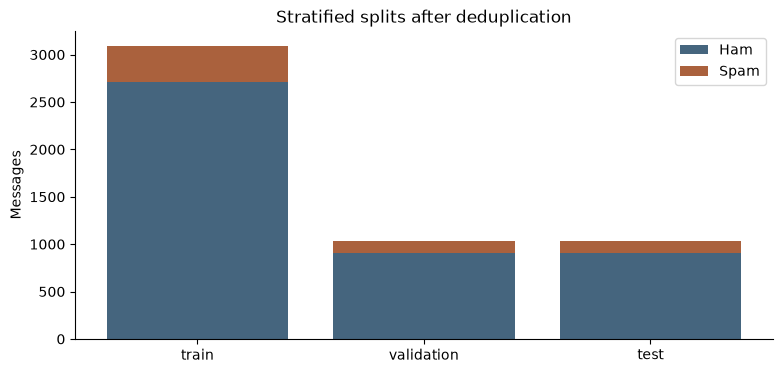

0 No management puzzeles.
0 Awesome, plan to get here any time after like  &lt;#&gt; , I'll text you details in a wee bit
0 I'm outside islands, head towards hard rock and you'll run into me
0 Tmrw. Im finishing 9 doors


In [9]:
names = list(initial["counts"])
ham = [initial["counts"][name]["ham"] for name in names]
spam = [initial["counts"][name]["spam"] for name in names]
plt.bar(names, ham, label="Ham", color=HAM)
plt.bar(names, spam, bottom=ham, label="Spam", color=SPAM)
plt.ylabel("Messages")
plt.title("Stratified splits after deduplication")
plt.legend()
plt.show()
for item in initial["examples"][:4]:
    print(item["label"], item["text"])

### Run and explain

Compute accuracy and spam recall for the always-ham baseline. Why do we remove duplicates before splitting?

In [10]:
print("Training / validation:", len(X_train), len(X_val))
print("Training spam proportion:", y_train.mean())
baseline = metrics(y_val, np.zeros(len(y_val)))
print("Always-ham accuracy:", baseline["accuracy"])
print("Always-ham recall:", baseline["recall"])

Training / validation: 3095 1032
Training spam proportion: 0.12439418416801293
Always-ham accuracy: 0.875
Always-ham recall: 0.0


**Takeaway:** Accuracy alone can hide a useless filter. Always check the class balance and the spam recall.

## 3. Build observable features

**What can we measure before understanding language?**

**Key idea:** Turn each message into a few numbers a model can use.

- Measure five things: characters, words, links, digits and exclamation marks.
- Spam tends to be longer and to contain more digits (prices, phone numbers), but the two classes overlap.
- Counts are skewed, so take log(1+x), then standardize with the training mean and standard deviation.
- Five numbers lose most of the meaning: very different messages can share the same counts.

$$u_j=\log(1+x_j),\qquad z_j=\frac{u_j-\mu_j}{s_j}$$

- $x_j$: raw count, e.g. number of digits
- $\mu_j,\ s_j$: mean and SD from training data only
- $z_j$: the value the model sees

**Try it**

1. Type a message and watch its five numbers.
2. Compare the ham and spam histograms for each feature.
3. Fit a logistic model on these five numbers as a baseline.

### Inspect the implementation: `numerical_features`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [11]:
def numerical_features(messages):
    """Hand-designed observations; no labels or fitted statistics are used."""
    return np.asarray([[len(s), len(tokens(s)),
                        len(re.findall(r'https?://|www\.', s, flags=re.I)),
                        sum(c.isdigit() for c in s), s.count('!')]
                       for s in messages], dtype=float)

science.numerical_features = numerical_features

### Inspect the implementation: `build_model`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [12]:
def build_model(kind='logistic', representation='count', C=1., k=5):
    """Keep every learned transformation inside the pipeline."""
    if representation == 'numeric' or kind in ('lda', 'gam'):
        steps = [('features', FunctionTransformer(numerical_features)),
                 ('log', FunctionTransformer(np.log1p))]
        if kind == 'gam':
            # Separate spline bases for each input; no feature interactions.
            steps += [('splines', SplineTransformer(n_knots=4, degree=3,
                                                    include_bias=False))]
        steps += [('scale', StandardScaler())]
    else:
        vectorizer = CountVectorizer if representation == 'count' else TfidfVectorizer
        steps = [('vectorizer', vectorizer(token_pattern=TOKEN_PATTERN, min_df=2,
                                          max_features=2500))]
    if kind == 'lda':
        classifier = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    elif kind == 'knn':
        classifier = KNeighborsClassifier(n_neighbors=int(k), algorithm='brute',
                                           metric='euclidean' if representation == 'numeric' else 'cosine')
    else:
        classifier = LogisticRegression(C=float(C), solver='liblinear', max_iter=1000,
                                         random_state=SEED)
    return Pipeline(steps + [('classifier', classifier)])

science.build_model = build_model

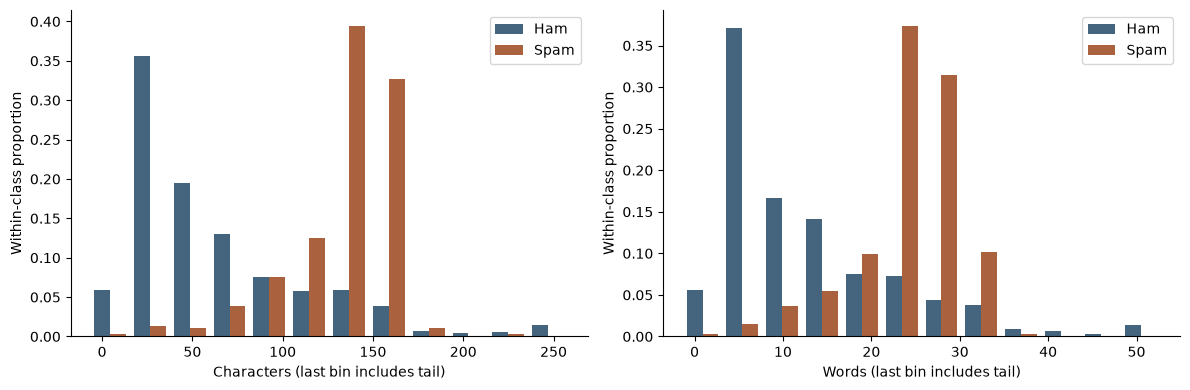

Numerical logistic validation: {'accuracy': 0.9786821705426356, 'precision': 0.9421487603305785, 'recall': 0.8837209302325582, 'f1': 0.9119999999999999, 'confusion': [[896, 7], [15, 114]], 'false_positive_rate': 0.007751937984496124, 'log_loss': 0.07656444884694863, 'average_precision': 0.9504656038391324, 'roc_auc': 0.9825688703460471}


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for j, ax in enumerate(axes):
    d = initial["distributions"][j]
    width = np.diff(d["edges"])[0]
    centers = np.asarray(d["edges"][:-1])
    for label, color in [(0, HAM), (1, SPAM)]:
        ax.bar(centers + label * width * .4, d["groups"][label], width=width * .4, color=color, label="Ham" if label == 0 else "Spam")
    ax.set(xlabel=d["name"] + " (last bin includes tail)", ylabel="Within-class proportion")
    ax.legend()
plt.tight_layout()
plt.show()
numeric_run = lab.fit({"representation": "numeric"})
print("Numerical logistic validation:", numeric_run["validation"])

### Run and explain

Write two very different messages with the same five numbers. What can this representation not see?

In [14]:
texts = ["Are you free at 8?", "WIN £1000! Visit https://example.org now!!!"]
print("Characters, words, links, digits, exclamations:")
print(numerical_features(texts))
model = build_model(representation="numeric")
model.fit(X_train, y_train)
print("Numerical baseline AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])

Characters, words, links, digits, exclamations:
[[18.  5.  0.  1.  0.]
 [43.  7.  1.  4.  4.]]
Numerical baseline AP: 0.9504656038391324


**Takeaway:** Every representation keeps some evidence and throws the rest away.

## 4. Turn words into vectors

**How can the model use the actual words?**

**Key idea:** Give every word its own column.

- Split text into lowercase words (tokens). The training vocabulary defines the columns.
- Bag of words: each cell counts how often that word appears. Word order is lost.
- A new message reuses the same columns. Words not in the vocabulary are ignored.
- TF–IDF gives less weight to words that appear in many documents, then scales each row to length 1.

$$\mathrm{idf}_j=\log\frac{1+n}{1+\mathrm{df}_j}+1,\qquad x_j=\frac{\mathrm{count}_j\cdot\mathrm{idf}_j}{\|\cdot\|_2}$$

- $n$: number of training documents
- $\mathrm{df}_j$: documents that contain word j
- $\|\cdot\|_2$: each row is scaled to length 1

**Try it**

1. Click a word to highlight its column.
2. Switch between counts and TF–IDF.
3. Add an unseen word to the new message. Where does it go?

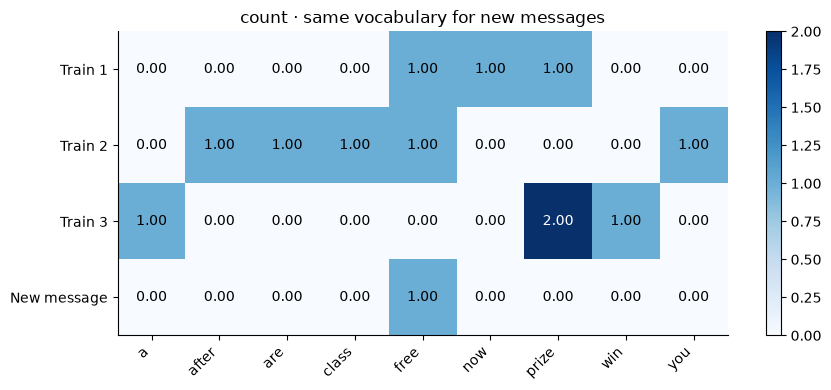

Ignored words: ['meeting', 'tomorrow']


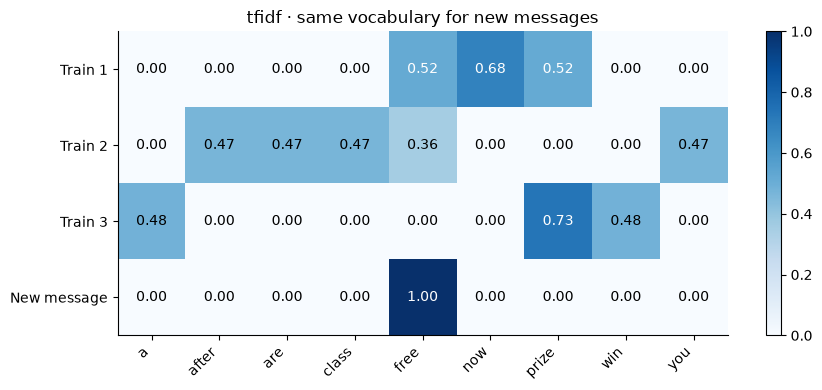

Ignored words: ['meeting', 'tomorrow']


In [15]:
toy = ["free prize now", "are you free after class", "win a prize prize"]
for representation in ["count", "tfidf"]:
    result = lab.vectorize({"documents": toy, "text": "free meeting tomorrow", "representation": representation})
    fig, ax = plt.subplots()
    matrix = np.vstack([result["matrix"], result["transformed"]])
    image = ax.imshow(matrix, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(result["vocabulary"])), result["vocabulary"], rotation=45, ha="right")
    ax.set_yticks(range(4), ["Train 1", "Train 2", "Train 3", "New message"])
    for (row, col), value in np.ndenumerate(matrix):
        ax.text(col, row, f"{value:.2f}", ha="center", va="center", color="white" if value > matrix.max() / 2 else "black")
    ax.set_title(representation + " · same vocabulary for new messages")
    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()
    print("Ignored words:", result["unknown"])

### Run and explain

Repeat a word, reorder the sentence, add an unseen word. What changes in counts and in TF–IDF?

In [16]:
vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b[a-z0-9]+\b")
toy = ["free prize now", "are you free after class", "win a prize prize"]
X = vectorizer.fit_transform(toy)
print("Vocabulary:", vectorizer.get_feature_names_out())
print("IDF:", np.round(vectorizer.idf_, 3))
print("New message:", vectorizer.transform(["free meeting tomorrow"]).toarray())

Vocabulary: ['a' 'after' 'are' 'class' 'free' 'now' 'prize' 'win' 'you']
IDF: [1.693 1.693 1.693 1.693 1.288 1.693 1.288 1.693 1.693]
New message: [[0. 0. 0. 0. 1. 0. 0. 0. 0.]]


**Takeaway:** fit learns the vocabulary from training data; transform reuses it. Never refit on new messages.

## 5. Learn a weighted rule

**How do word counts become a spam score?**

**Key idea:** Logistic regression learns how much each word counts as evidence.

- Score z = bias + Σ weight × feature. Positive terms push towards spam, negative towards ham.
- The sigmoid turns z into a probability p. With threshold 0.5: spam exactly when z ≥ 0.
- Explain one prediction with its contributions wⱼxⱼ. A word that is not in the message contributes 0.
- Training minimizes cross-entropy, as in Tutorial04; sklearn does the optimization.

$$z=b+\sum_j w_jx_j,\qquad p=\sigma(z)=\frac{1}{1+e^{-z}}$$

- $w_jx_j$: contribution of word j to this message
- $b$: bias (intercept)
- $p$: estimated P(spam | message)

**Try it**

1. Fit a classifier on word counts or TF–IDF.
2. Read the message's word contributions and where it lands on the sigmoid.
3. Change one word and predict the new score before you check.

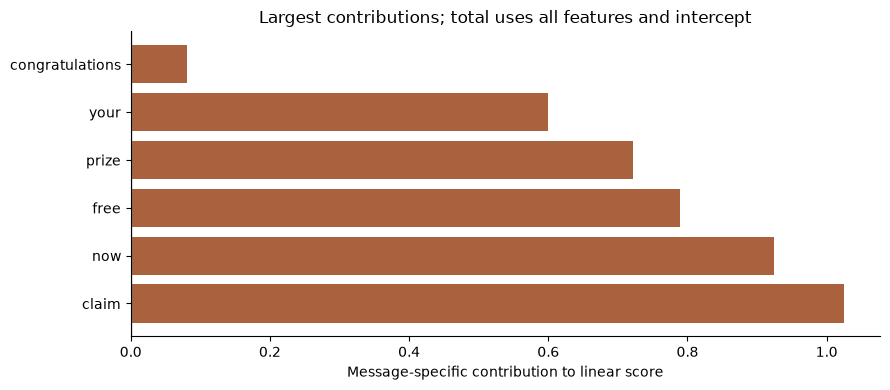

Intercept / score / probability: -4.403354723267205 -0.2636608189796572 0.4344640116979819


In [17]:
count_run = lab.fit({"representation": "count", "C": 1})
tfidf_run = lab.fit({"representation": "tfidf", "C": 1})
explanation = lab.explain({"id": count_run["id"], "text": "Congratulations! Claim your free prize now!"})
items = explanation["contributions"][:14]
plt.barh([item["name"] for item in items], [item["value"] for item in items], color=[SPAM if item["value"] > 0 else HAM for item in items])
plt.axvline(0, color="grey", linewidth=1)
plt.xlabel("Message-specific contribution to linear score")
plt.title("Largest contributions; total uses all features and intercept")
plt.tight_layout()
plt.show()
print("Intercept / score / probability:", explanation["bias"], explanation["score"], explanation["probability"])

### Run and explain

Swap a spammy word for a normal one. How do the contributions, score and probability change?

In [18]:
model = build_model(representation="count", C=1)
model.fit(X_train, y_train)
text = "Congratulations claim your free prize now"
x = model[:-1].transform([text])
w = model.named_steps["classifier"].coef_[0]
b = model.named_steps["classifier"].intercept_[0]
z = float((x @ w)[0]) + b
print("Score / probability:", z, 1 / (1 + np.exp(-z)))
print("Validation AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])

Score / probability: -0.2636608189796572 0.4344640116979819
Validation AP: 0.962836497746499


**Takeaway:** Contributions explain the model's arithmetic, not cause and effect.

## 6. Control the fitted rule

**Should one rare word receive a huge weight?**

**Key idea:** Penalize large weights so that rare words cannot dominate.

- There are 2,500 word columns but only 385 training spam messages. Some words look decisive just by chance.
- The L2 penalty shrinks weights towards 0. In sklearn, smaller C means a stronger penalty.
- Too strong: the model underfits. Too weak: it memorizes training noise. Watch the gap between training and validation.

$$\min_{\mathbf w,b}\ \sum_i \ell(y_i,p_i)+\lambda\|\mathbf w\|_2^2,\qquad C\approx 1/\lambda$$

- $\ell$: cross-entropy loss
- $\lambda$: penalty strength
- $C$: sklearn's inverse penalty: small C, strong penalty

**Try it**

1. Fit the same model for five values of C.
2. Follow individual word weights as the penalty weakens.
3. Compare training and validation AP.

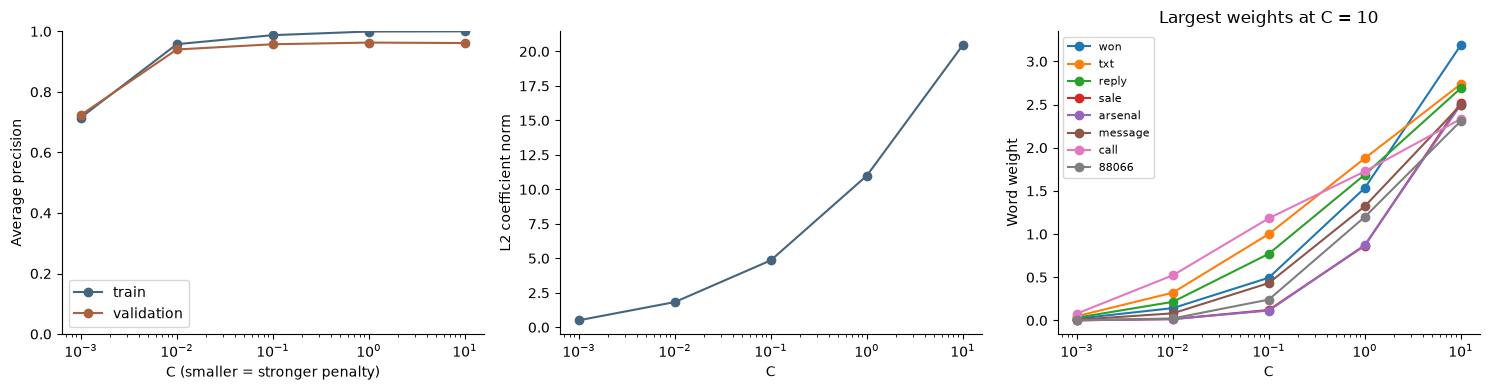

In [19]:
sweep = lab.regularization({"representation": "count"})
Cs = [row["C"] for row in sweep["rows"]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for split, color in [("train", HAM), ("validation", SPAM)]:
    axes[0].semilogx(Cs, [row[split]["average_precision"] for row in sweep["rows"]], "o-", label=split, color=color)
axes[0].set(xlabel="C (smaller = stronger penalty)", ylabel="Average precision", ylim=(0, 1))
axes[0].legend()
axes[1].semilogx(Cs, sweep["weights"], "o-", color=HAM)
axes[1].set(xlabel="C", ylabel="L2 coefficient norm")
for path in sweep["paths"]:
    axes[2].semilogx(Cs, path["weights"], "o-", label=path["word"])
axes[2].set(xlabel="C", ylabel="Word weight", title="Largest weights at C = 10")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Run and explain

Which C gives the best validation AP? Did larger weights help?

In [20]:
for C in [.001, .01, .1, 1, 10]:
    model = build_model(C=C)
    model.fit(X_train, y_train)
    p = model.predict_proba(X_val)[:, 1]
    norm = np.linalg.norm(model.named_steps["classifier"].coef_)
    print(f"C={C:g}, weight norm={norm:.3f}, validation AP={metrics(y_val, p)["average_precision"]:.3f}")

C=0.001, weight norm=0.509, validation AP=0.724
C=0.01, weight norm=1.830, validation AP=0.940
C=0.1, weight norm=4.855, validation AP=0.957
C=1, weight norm=10.993, validation AP=0.963
C=10, weight norm=20.461, validation AP=0.961


**Takeaway:** C controls how the model is fitted; the threshold controls decisions afterwards. They are different knobs.

## 7. Select with cross-validation

**What must be fitted again inside each fold?**

**Key idea:** Cross-validation tests the whole pipeline, not just the classifier.

- Split the training data into 5 folds. Fit on 4, score the 5th, rotate, then average.
- The vocabulary and IDF are learned too. Refit them inside every fold, or held-out words leak into training.
- Pick the C with the best mean score, then refit on all training data.

$$\mathrm{CV}(C)=\frac{1}{5}\sum_{f=1}^{5}\mathrm{AP}_f(C)$$

- $f$: the held-out fold
- $\mathrm{AP}_f(C)$: average precision on fold f; the pipeline is fitted without it
- $\mathrm{AP}$: area-like summary of the precision–recall curve

**Try it**

1. Pick a held-out fold and see which data fit the pipeline.
2. Run CV and compare the five fold scores for each C.
3. Refit the chosen C on all training data.

### Inspect the implementation: `cross_validate`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [21]:
def cross_validate(messages, labels, representation='count', values=(.01, .1, 1., 10.)):
    """Fit vocabulary, IDF and model afresh inside EACH training fold."""
    folds = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(messages, labels))
    rows = []
    for C in values:
        scores, training, vocabulary_sizes = [], [], []
        for train, heldout in folds:
            model = build_model(C=C, representation=representation)
            model.fit(messages[train], labels[train])
            scores.append(average_precision_score(labels[heldout], model.predict_proba(messages[heldout])[:, 1]))
            training.append(average_precision_score(labels[train], model.predict_proba(messages[train])[:, 1]))
            vocabulary_sizes.append(len(model.named_steps['vectorizer'].vocabulary_))
        rows.append({'C': C, 'folds': list(map(float, scores)), 'train': float(np.mean(training)),
                     'mean': float(np.mean(scores)), 'std': float(np.std(scores, ddof=1)),
                     'vocabulary_sizes': vocabulary_sizes})
    return rows

science.cross_validate = cross_validate

C: 0.01 fold AP: [0.931 0.955 0.95  0.94  0.917] mean ± SD: 0.938 0.015
C: 0.1 fold AP: [0.967 0.972 0.97  0.971 0.939] mean ± SD: 0.964 0.014
C: 1.0 fold AP: [0.98  0.973 0.968 0.974 0.946] mean ± SD: 0.968 0.013
C: 10.0 fold AP: [0.97  0.972 0.964 0.963 0.944] mean ± SD: 0.963 0.011


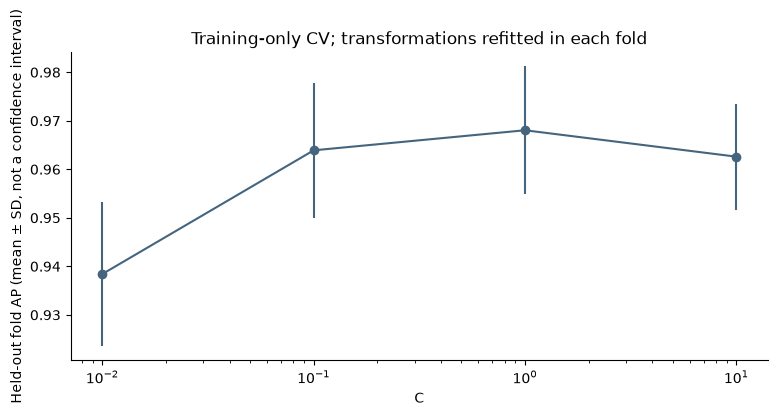

Selected C: 1.0
Fold vocabulary sizes: [2346, 2303, 2336, 2389, 2333]
Held-out words absent from retained fold vocabulary: ['07', '07008009200', '07090298926', '07734396839', '07742676969', '08001950382', '08002888812', '0844', '0870', '08700621170150p', '08701417012150p', '087016248', '08704050406', '08707509020', '08709222922', '087104711148']


In [22]:
cv_result = lab.cv({"representation": "count"})
for row in cv_result["rows"]:
    print("C:", row["C"], "fold AP:", np.round(row["folds"], 3), "mean ± SD:", round(row["mean"], 3), round(row["std"], 3))
means = [row["mean"] for row in cv_result["rows"]]
std = [row["std"] for row in cv_result["rows"]]
plt.errorbar([row["C"] for row in cv_result["rows"]], means, yerr=std, fmt="o-", color=HAM)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Held-out fold AP (mean ± SD, not a confidence interval)")
plt.title("Training-only CV; transformations refitted in each fold")
plt.show()
print("Selected C:", cv_result["best"])
print("Fold vocabulary sizes:", cv_result["rows"][0]["vocabulary_sizes"])
print("Held-out words absent from retained fold vocabulary:", cv_result["fold_unknown"])

### Run and explain

Why can the vocabulary size differ between folds, and why is that correct?

In [23]:
rows = cross_validate(X_train, y_train, representation="count")
for row in rows:
    print("C / fold AP / mean:", row["C"], np.round(row["folds"], 3), round(row["mean"], 3))
print("Selected C:", max(rows, key=lambda r: r["mean"])["C"])

C / fold AP / mean: 0.01 [0.931 0.955 0.95  0.94  0.917] 0.938
C / fold AP / mean: 0.1 [0.967 0.972 0.97  0.971 0.939] 0.964
C / fold AP / mean: 1.0 [0.98  0.973 0.968 0.974 0.946] 0.968
C / fold AP / mean: 10.0 [0.97  0.972 0.964 0.963 0.944] 0.963
Selected C: 1.0


**Takeaway:** Leakage-free CV gives a fair choice of C. Only the test set gives the final, unbiased number.

## 8. Model the class distributions

**What changes if we model the features within each class?**

**Key idea:** LDA models what each class looks like, then applies Bayes' rule.

- Assume each class is Gaussian, with its own mean and a shared covariance.
- A shared covariance makes the boundary linear, like logistic regression, but it is reached differently.
- The class prior (88% ham) moves the boundary towards the rarer spam class.
- We use the five numerical features; a Gaussian model does not suit 2,500 sparse word counts.

$$\log\frac{P(\text{spam}\mid\mathbf x)}{P(\text{ham}\mid\mathbf x)}=(\boldsymbol\mu_1-\boldsymbol\mu_0)^\top\Sigma^{-1}\mathbf x+b$$

- $\boldsymbol\mu_0,\boldsymbol\mu_1$: class means (ham, spam)
- $\Sigma$: shared covariance
- $b$: includes the log prior ratio

**Try it**

1. Fit LDA on the five numerical features.
2. Read the class means, covariance ellipses and boundary.
3. Compare with numerical logistic regression: same inputs, different model.

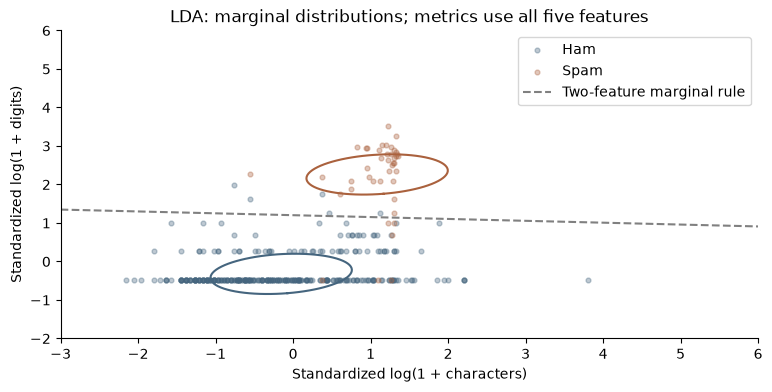

LDA validation: {'accuracy': 0.9786821705426356, 'precision': 0.9349593495934959, 'recall': 0.8914728682170543, 'f1': 0.9126984126984128, 'confusion': [[895, 8], [14, 115]], 'false_positive_rate': 0.008859357696566999, 'log_loss': 0.18860124196358394, 'average_precision': 0.9486376680655596, 'roc_auc': 0.9807231708259292}
Numerical logistic comparison: {'accuracy': 0.9786821705426356, 'precision': 0.9421487603305785, 'recall': 0.8837209302325582, 'f1': 0.9119999999999999, 'confusion': [[896, 7], [15, 114]], 'false_positive_rate': 0.007751937984496124, 'log_loss': 0.07656444884694863, 'average_precision': 0.9504656038391324, 'roc_auc': 0.9825688703460471}


In [24]:
lda_result = lab.lda({})
fig, ax = plt.subplots()
for label, color in [(0, HAM), (1, SPAM)]:
    points = np.asarray([[p["x"], p["y"]] for p in lda_result["points"] if p["label"] == label])
    ax.scatter(points[:, 0], points[:, 1], s=12, alpha=.35, color=color, label="Ham" if label == 0 else "Spam")
    ellipse = np.asarray(lda_result["ellipses"][label])
    ax.plot(ellipse[:, 0], ellipse[:, 1], color=color)
wx, wy = lda_result["boundary"]["w"]
b = lda_result["boundary"]["b"]
x = np.linspace(-3, 6, 50)
if abs(wy) > 1e-9:
    ax.plot(x, -(wx * x + b) / wy, "--", color="grey", label="Two-feature marginal rule")
ax.set(xlabel="Standardized log(1 + characters)", ylabel="Standardized log(1 + digits)", xlim=(-3, 6), ylim=(-2, 6), title="LDA: marginal distributions; metrics use all five features")
ax.legend()
plt.show()
print("LDA validation:", lda_result["run"]["validation"])
print("Numerical logistic comparison:", numeric_run["validation"])

### Run and explain

Compare LDA with logistic regression on the same five features. Which assumption could be wrong here?

In [25]:
for kind in ["logistic", "lda"]:
    model = build_model(kind=kind, representation="numeric")
    model.fit(X_train, y_train)
    p = model.predict_proba(X_val)[:, 1]
    print(kind, "validation AP:", metrics(y_val, p)["average_precision"])

logistic validation AP: 0.9504656038391324
lda validation AP: 0.9486376680655596


**Takeaway:** Compare models on the same inputs, so that a difference comes from the model and not the features.

## 9. Allow smooth feature effects

**Must each extra character change the score by the same amount?**

**Key idea:** Let each feature bend: a smooth curve instead of a straight line.

- Logistic regression: each feature adds wⱼxⱼ, a straight line in log-odds.
- Additive model (GAM): each feature adds its own smooth curve fⱼ, built from spline pieces.
- Still additive: no interactions between features.
- Here: sklearn SplineTransformer followed by L2-penalized logistic regression.

$$\log\frac{p}{1-p}=b+\sum_{j=1}^{5}f_j(x_j),\qquad f_j(x)=\sum_m\beta_{jm}B_{m}(x)$$

- $f_j$: smooth effect of feature j
- $B_m$: cubic spline basis function
- $\beta_{jm}$: fitted coefficients

**Try it**

1. Fit the additive model on the five numerical features.
2. Read each curve: where does it bend?
3. Compare with numerical logistic regression and LDA.

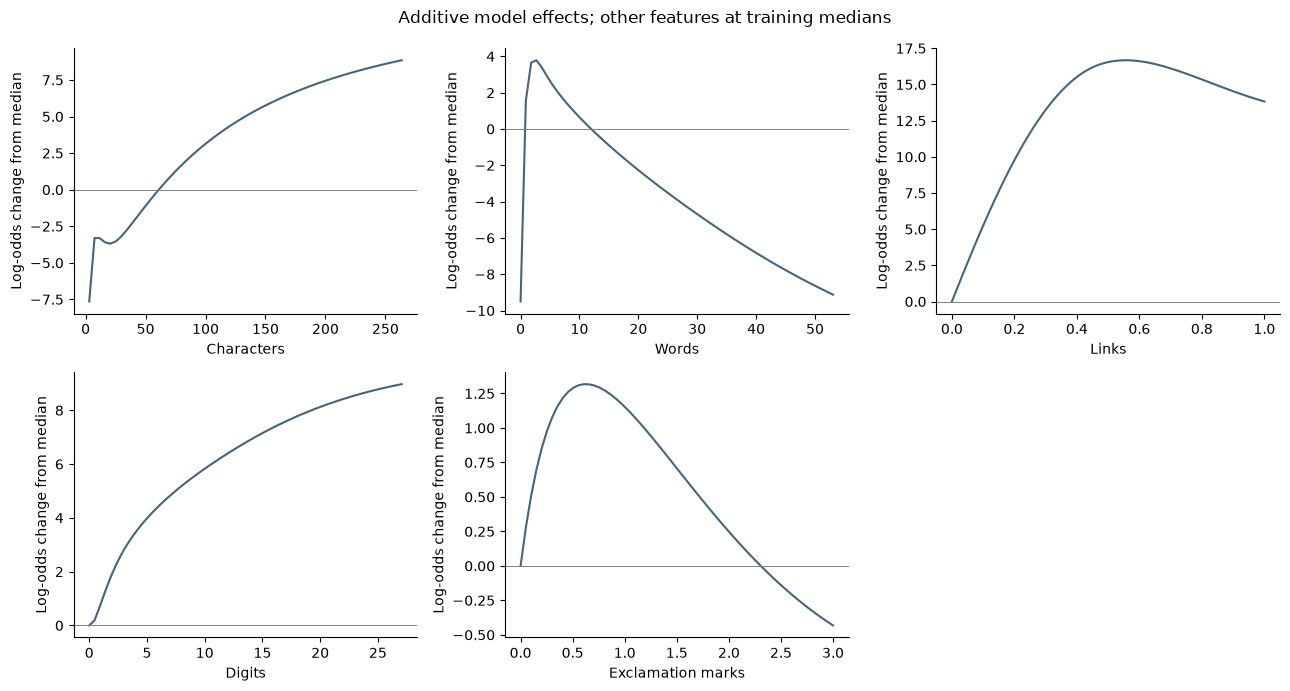

Reference values: [61.0, 12.0, 0.0, 0.0, 0.0]
Additive model validation: {'accuracy': 0.9825581395348837, 'precision': 0.9743589743589743, 'recall': 0.8837209302325582, 'f1': 0.9268292682926831, 'confusion': [[900, 3], [15, 114]], 'false_positive_rate': 0.0033222591362126247, 'log_loss': 0.0653329728499026, 'average_precision': 0.9608942465924359, 'roc_auc': 0.9864577163116914}


In [26]:
gam_result = lab.gam({"C": 1})
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for curve, ax in zip(gam_result["curves"], axes.flat):
    ax.plot(curve["x"], curve["effect"], color=HAM)
    ax.axhline(0, color="grey", linewidth=.7)
    ax.set(xlabel=curve["name"], ylabel="Log-odds change from median")
axes.flat[-1].axis("off")
fig.suptitle("Additive model effects; other features at training medians")
plt.tight_layout()
plt.show()
print("Reference values:", gam_result["reference"])
print("Additive model validation:", gam_result["run"]["validation"])

### Run and explain

Find a curve that is clearly not straight. What would one constant weight miss?

In [27]:
for kind in ["logistic", "gam"]:
    model = build_model(kind=kind, representation="numeric", C=1)
    model.fit(X_train, y_train)
    print(kind, "validation AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])

logistic validation AP: 0.9504656038391324
gam validation AP: 0.9608942465924359


**Takeaway:** Flexibility can help or overfit. Validation decides.

## 10. Learn from similar messages

**What makes two messages neighbours?**

**Key idea:** KNN classifies a message by asking its k most similar training messages.

- Nothing to fit: store the training set, find the k nearest, report the spam fraction.
- Similarity is a choice: Euclidean distance on standardized numbers, cosine distance on word vectors.
- Small k: local and noisy. Large k: smoother, but drifts towards the majority class (ham).

$$\hat p(\mathbf x)=\frac{1}{k}\sum_{i\in N_k(\mathbf x)}y_i,\qquad d_{\cos}=1-\frac{\mathbf x^\top\mathbf x_i}{\|\mathbf x\|\,\|\mathbf x_i\|}$$

- $N_k(\mathbf x)$: the k nearest training messages
- $k$: number of neighbours
- $d_{\cos}$: cosine distance

**Try it**

1. Choose a representation and k, then fit.
2. Read the neighbours that voted for your message.
3. Compare the vote with logistic regression.

In [28]:
knn_run = lab.fit({"kind": "knn", "representation": "tfidf", "k": 5})
neighbours = lab.explain({"id": knn_run["id"], "text": "Claim your free prize now"})
for item in neighbours["neighbors"]:
    print("Distance:", round(item["distance"], 3), "label:", item["label"], "text:", item["text"])
print("Spam vote:", neighbours["probability"])
print("KNN validation:", knn_run["validation"])

Distance: 0.588 label: 0 text: Are you free now?can i call now?
Distance: 0.665 label: 1 text: URGENT This is our 2nd attempt to contact U. Your £900 prize from YESTERDAY is still awaiting collection. To claim CALL NOW 09061702893. ACL03530150PM
Distance: 0.665 label: 1 text: URGENT This is our 2nd attempt to contact U. Your £900 prize from YESTERDAY is still awaiting collection. To claim CALL NOW 09061702893
Distance: 0.678 label: 1 text: Win a £1000 cash prize or a prize worth £5000
Distance: 0.683 label: 1 text: Hi, this is Mandy Sullivan calling from HOTMIX FM...you are chosen to receive £5000.00 in our Easter Prize draw.....Please telephone 09041940223 to claim before 29/03/05 or your prize will be transferred to someone else....
Spam vote: 0.8
KNN validation: {'accuracy': 0.9757751937984496, 'precision': 0.9814814814814815, 'recall': 0.8217054263565892, 'f1': 0.8945147679324895, 'confusion': [[901, 2], [23, 106]], 'false_positive_rate': 0.0022148394241417496, 'log_loss': 0.181035

### Run and explain

Compare k = 3 and k = 15. Which new neighbours join the vote?

In [29]:
model = build_model(kind="knn", representation="tfidf", k=5)
model.fit(X_train, y_train)
text = "claim your free prize now"
vector = model[:-1].transform([text])
distance, index = model.named_steps["classifier"].kneighbors(vector)
for d, i in zip(distance[0], index[0]):
    print(round(d, 3), "spam" if y_train[i] else "ham", X_train[i])
print("Spam vote:", model.predict_proba([text])[0, 1])

0.588 ham Are you free now?can i call now?
0.665 spam URGENT This is our 2nd attempt to contact U. Your £900 prize from YESTERDAY is still awaiting collection. To claim CALL NOW 09061702893. ACL03530150PM
0.665 spam URGENT This is our 2nd attempt to contact U. Your £900 prize from YESTERDAY is still awaiting collection. To claim CALL NOW 09061702893
0.678 spam Win a £1000 cash prize or a prize worth £5000
0.683 spam Hi, this is Mandy Sullivan calling from HOTMIX FM...you are chosen to receive £5000.00 in our Easter Prize draw.....Please telephone 09041940223 to claim before 29/03/05 or your prize will be transferred to someone else....
Spam vote: 0.8


**Takeaway:** Always look at the neighbours: “nearest” does not always mean similar in meaning.

## 11. Choose the final decision

**How should scores become inbox actions?**

**Key idea:** A threshold turns scores into actions. Choose it on validation, then test once.

- Raise the threshold: fewer messages flagged, so fewer false alarms but more missed spam.
- Precision = TP/(TP+FP): of the flagged messages, how many are spam? Recall = TP/(TP+FN): of all spam, how much is caught?
- The PR and ROC curves show every threshold at once; average precision (AP) summarizes the ranking.
- Write down your choice and reason, then evaluate the test set once.

$$\hat y=\mathbb{1}[p\geq t],\qquad \text{Precision}=\frac{TP}{TP+FP},\quad \text{Recall}=\frac{TP}{TP+FN}$$

- $t$: decision threshold
- $FP$: ham blocked (false alarm)
- $FN$: spam let through (miss)

**Try it**

1. Pick a candidate model and move the threshold.
2. Watch the score histograms, confusion matrix and curves change together.
3. Write your reason, freeze the decision, run the test.

Candidate comparisons on validation; threshold metrics here use 0.5
run1 logistic numeric C 1.0 k 5 AP 0.95 precision 0.942 recall 0.884
run2 logistic count C 1.0 k 5 AP 0.963 precision 0.974 recall 0.868
run3 logistic tfidf C 1.0 k 5 AP 0.972 precision 1.0 recall 0.767
run4 logistic count C 0.001 k 5 AP 0.724 precision 0.0 recall 0.0
run5 logistic count C 0.01 k 5 AP 0.94 precision 0.987 recall 0.574
run6 logistic count C 0.1 k 5 AP 0.957 precision 0.972 recall 0.814
run7 logistic count C 1.0 k 5 AP 0.963 precision 0.974 recall 0.868
run8 logistic count C 10.0 k 5 AP 0.961 precision 0.958 recall 0.876
run9 logistic count C 1.0 k 5 AP 0.963 precision 0.974 recall 0.868
run10 lda numeric C 1.0 k 5 AP 0.949 precision 0.935 recall 0.891
run11 gam numeric C 1.0 k 5 AP 0.961 precision 0.974 recall 0.884
run12 knn tfidf C 1.0 k 5 AP 0.943 precision 0.981 recall 0.822
Selected validation metrics: {'accuracy': 0.9806201550387597, 'precision': 0.9739130434782609, 'recall': 0.8682170542635659, '

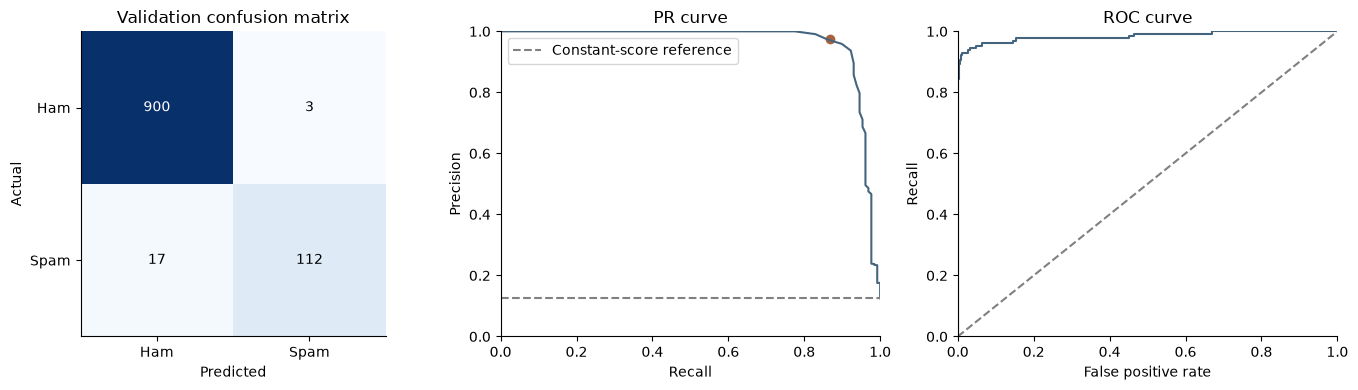

True 1 predicted 0 p 0.003 Hi I'm sue. I am 20 years old and work as a lapdancer. I love sex. Text me live - I'm i my bedroom now. text SUE to 89555. By TextOperator G2 1DA 150ppmsg 18+
True 1 predicted 0 p 0.007 Sorry I missed your call let's talk when you have the time. I'm on 07090201529
True 1 predicted 0 p 0.007 ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT. BAILIFF DUE IN DAYS. I O £250 3 WANT £800
True 1 predicted 0 p 0.019 08714712388 between 10am-7pm Cost 10p
True 1 predicted 0 p 0.02 Did you hear about the new "Divorce Barbie"? It comes with all of Ken's stuff!
True 1 predicted 0 p 0.044 Would you like to see my XXX pics they are so hot they were nearly banned in the uk!
True 1 predicted 0 p 0.057 RCT' THNQ Adrian for U text. Rgds Vatian
True 1 predicted 0 p 0.081 88800 and 89034 are premium phone services call 08718711108


In [30]:
print("Candidate comparisons on validation; threshold metrics here use 0.5")
for item in lab.runs.values():
    row = item["row"]
    print(row["id"], row["kind"], row["representation"], "C", row["C"], "k", row["k"], "AP", round(row["validation"]["average_precision"], 3), "precision", round(row["validation"]["precision"], 3), "recall", round(row["validation"]["recall"], 3))

# Edit using validation evidence before executing the final test cell.
selected_id = cv_result["run"]["id"]
threshold = .5
validation_result = lab.evaluate({"id": selected_id, "threshold": threshold})
print("Selected validation metrics:", validation_result["metrics"])
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cm = np.asarray(validation_result["metrics"]["confusion"])
axes[0].imshow(cm, cmap="Blues")
for (r, c), value in np.ndenumerate(cm):
    axes[0].text(c, r, str(value), ha="center", va="center", color="white" if value > cm.max()/2 else "black")
axes[0].set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"], xlabel="Predicted", ylabel="Actual", title="Validation confusion matrix")
pr, roc = np.asarray(validation_result["pr"]), np.asarray(validation_result["roc"])
axes[1].plot(pr[:, 0], pr[:, 1], color=HAM)
axes[1].axhline(validation_result["prevalence"], ls="--", color="grey", label="Constant-score reference")
axes[1].scatter(validation_result["metrics"]["recall"], validation_result["metrics"]["precision"], color=SPAM)
axes[1].set(xlabel="Recall", ylabel="Precision", title="PR curve", xlim=(0,1), ylim=(0,1))
axes[1].legend()
axes[2].plot(roc[:, 0], roc[:, 1], color=HAM)
axes[2].plot([0,1], [0,1], "--", color="grey")
axes[2].set(xlabel="False positive rate", ylabel="Recall", title="ROC curve", xlim=(0,1), ylim=(0,1))
plt.tight_layout()
plt.show()
for item in validation_result["errors"][:8]:
    print("True", item["label"], "predicted", item["prediction"], "p", round(item["probability"], 3), item["text"])

### Run and explain

Justify your threshold with validation evidence. Then report the frozen decision's test result and one limitation of the data.

In [31]:
model = build_model(representation="tfidf", C=1)
model.fit(X_train, y_train)
p = model.predict_proba(X_val)[:, 1]
for t in [.2, .5, .8]:
    result = metrics(y_val, p, t)
    print("Threshold:", t, "precision:", round(result["precision"], 3), "recall:", round(result["recall"], 3), "confusion:", result["confusion"])

Threshold: 0.2 precision: 0.917 recall: 0.946 confusion: [[892, 11], [7, 122]]
Threshold: 0.5 precision: 1.0 recall: 0.767 confusion: [[903, 0], [30, 99]]
Threshold: 0.8 precision: 1.0 recall: 0.233 confusion: [[903, 0], [99, 30]]


**Takeaway:** The test result describes this dataset split, not modern email.

## Freeze the decision and evaluate the test set

Write your own rationale using validation evidence, the inbox error tradeoff and a data limitation. This cell runs only when the rationale is nonempty. The lab freezes the selected model and threshold after testing. Restarting a kernel does not make a repeatedly inspected test set unseen again.

In [32]:
reason = ''  # Write your model and threshold rationale before testing.
if reason.strip():
    final_result = lab.final_test({'id': selected_id, 'threshold': threshold, 'reason': reason})
    print(json.dumps(final_result, indent=2))
else:
    print('Record a rationale above, then run the final test once.')

Record a rationale above, then run the final test once.


## Experiment record

Report the baseline, representation/model comparisons, CV result, threshold decision, representative errors and limits of generalizing from historical English SMS to modern email. A higher score alone is not an explanation.

In [33]:
record = {'dataset': 'Original UCI SMS Spam Collection', 'seed': SEED, 'splits': initial['counts'],
          'runs': [{k: v for k, v in item['row'].items() if k not in ('thresholds',)} for item in lab.runs.values()],
          'cv': cv_result['rows'], 'final': lab.final}
Path('tutorial05-results.json').write_text(json.dumps(record, indent=2))
print('Saved tutorial05-results.json')

Saved tutorial05-results.json
